# Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip3 install ydata-profiling
from ydata_profiling import ProfileReport
plt.style.use('fivethirtyeight')
sns.color_palette("pastel")
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 59.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=81cab718f82691504514c4fb29862b7906ef6eb6014daa062d219a4f2134fd3c
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7822 entries, 2024-01-16 00:00:00 to 2024-12-07 00:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   importActiveEnergyT  7822 non-null   float64
 1   currentA             7822 non-null   float64
 2   currentB             7822 non-null   float64
 3   currentC             7822 non-null   float64
 4   voltageA             7822 non-null   float64
 5   voltageB             7822 non-null   float64
 6   voltageC             7822 non-null   float64
 7   activePowerT         7822 non-null   float64
 8   activePowerA         7822 non-null   float64
 9   activePowerB         7822 non-null   float64
 10  activePowerC         7822 non-null   float64
 11  voltageL12           7318 non-null   float64
 12  voltageL23           7318 non-null   float64
 13  voltageL31           7318 non-null   float64
dtypes: float64(14)
memory usage: 916.6 KB


# Energy Consumption Data Graph

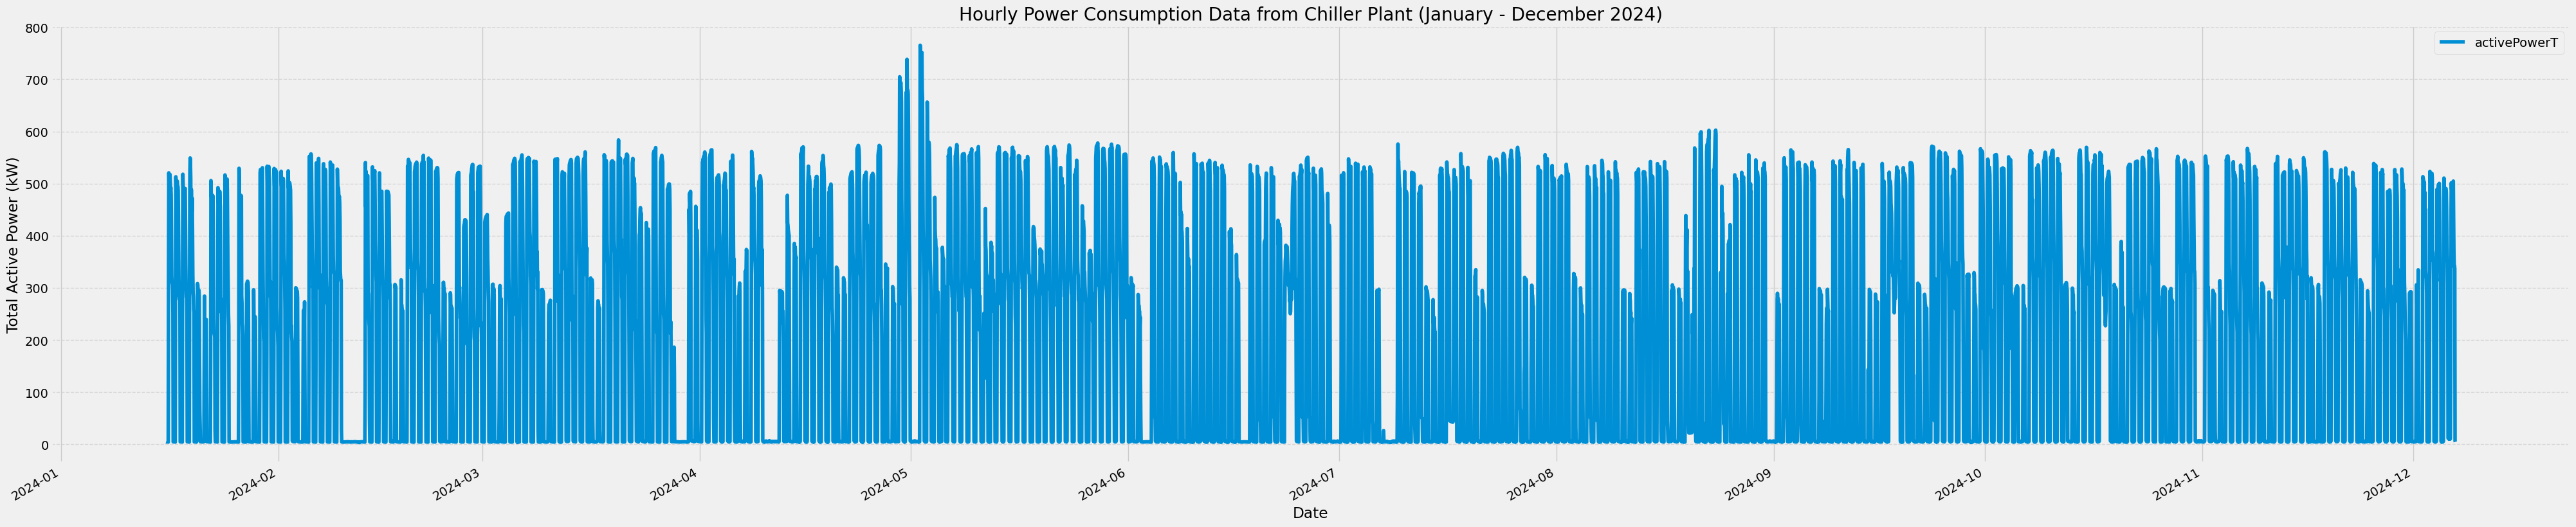

In [ ]:
img = df.plot( y=['activePowerT'], figsize=(45,10),title ='Hourly Power Consumption Data from Chiller Plant (January - December 2024)',xlabel='Date',ylabel='Total Active Power (kW)')
fig = img.get_figure()
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/Preliminary Analysis/Preliminary Analysis')

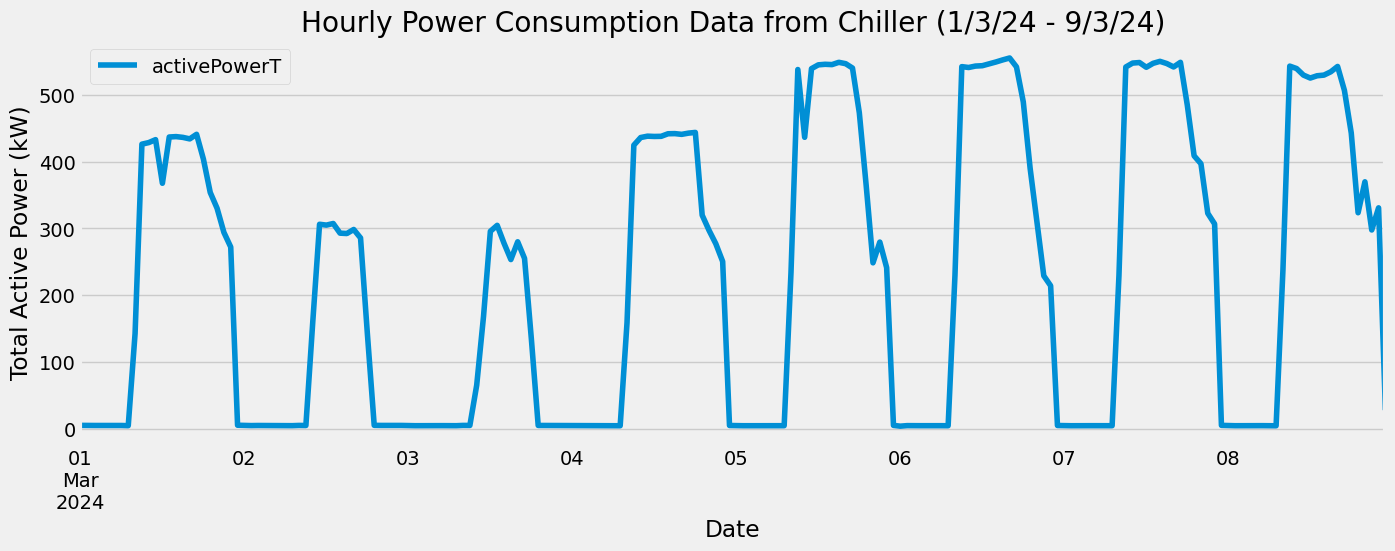

In [ ]:
img = df.loc[(df.index >= '2024-03-01') & (df.index < '2024-03-09')].plot(y=['activePowerT'], figsize=(15,5),title ='Hourly Power Consumption Data from Chiller (1/3/24 - 9/3/24)',xlabel='Date',ylabel='Total Active Power (kW)')
fig = img.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Preliminary Analysis/Preliminary Analysis (Week)')

It can be seen that the power consumption of Chiller follows a relatively fixed pattern with spikes of power consumption data and near zero power consumption. This is postulated as the chiller is turned off during the night to prevent power wastage. There are certain interesting outliers that break the pattern such as a flatline in the middle of the month of February. That phenomenon is the result of Chinese New Year holidays which happened between 10th to 17th February. This results in air conditioning in all faculty buildings turned off whereas most students would have returned home from on-campus accomodations.

# Data Profiling

In [ ]:
profile = ProfileReport(df, title="Pandas Profiling Report")
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

# Analysis

In [ ]:
def create_features(df, label=None):
    """
    Creates time series features from datetime index
    """
    df=df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7822 entries, 2024-01-16 00:00:00 to 2024-12-07 00:00:00
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   importActiveEnergyT  7822 non-null   float64
 1   currentA             7822 non-null   float64
 2   currentB             7822 non-null   float64
 3   currentC             7822 non-null   float64
 4   voltageA             7822 non-null   float64
 5   voltageB             7822 non-null   float64
 6   voltageC             7822 non-null   float64
 7   activePowerT         7822 non-null   float64
 8   activePowerA         7822 non-null   float64
 9   activePowerB         7822 non-null   float64
 10  activePowerC         7822 non-null   float64
 11  voltageL12           7318 non-null   float64
 12  voltageL23           7318 non-null   float64
 13  voltageL31           7318 non-null   float64
 14  hour                 7822 non-null   int32  
 15  da

# Relationship between Hour of Day & Total Active Power

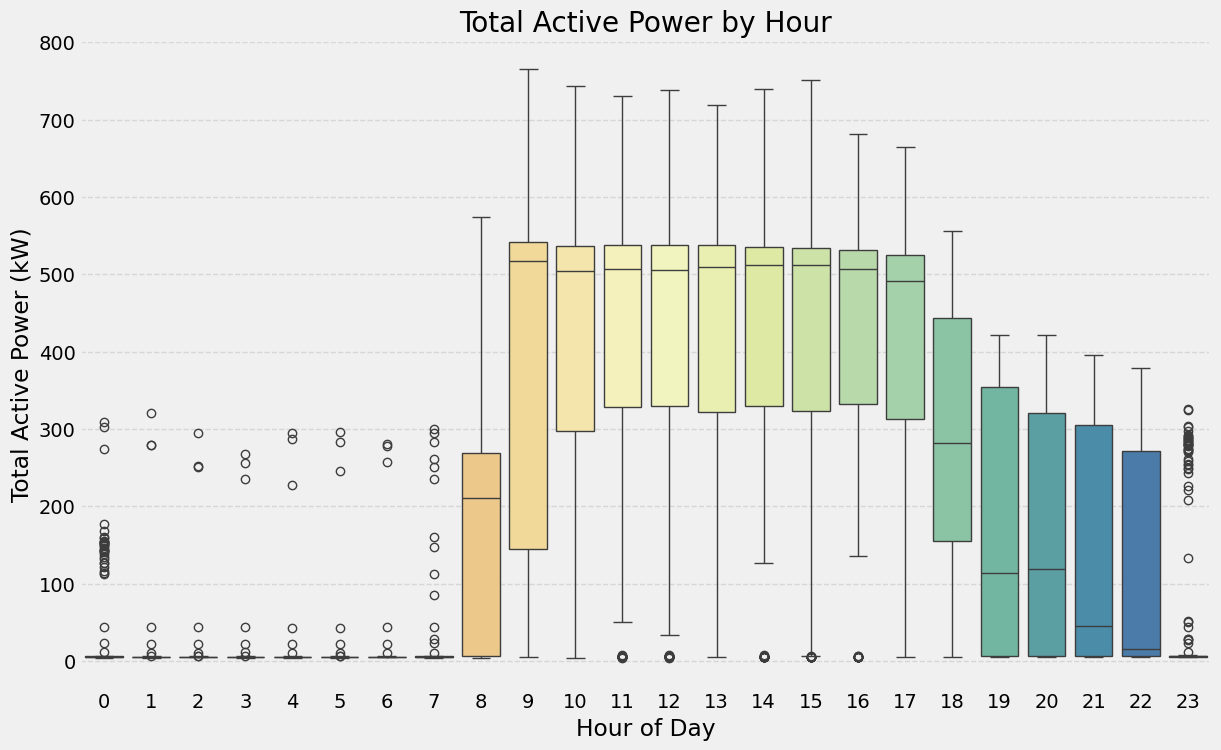

In [ ]:
fig, ax = plt.subplots(figsize=(13,8))
sns.boxplot(data=df, x='hour', y='activePowerT', ax=ax, palette='Spectral')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Active Power (kW)')
ax.set_title('Total Active Power by Hour')

fig.savefig('/content/drive/MyDrive/Images/Preliminary Analysis/Day of Hour Analysis')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the figure above, it can be determined that the general operating hours of the chiller plant is from 9 am to 11pm. The average active power consumption is approximately 500kW for most of the working hours which is around 10am to 5pm. This makes sense as most air conditioners would be turned off when most students leave. It is postulated that the power consumption in the evening is from air conditioners in accomodation block or Student Association buildings where the student activity is still going on. Another phenomenon worth observing is the outlier power consumption data found between 12am to 1am. It was postulated this was a special case when the library has extended operating hours for students to study during the exam period which usually takes place during may.

# Relationship between Day of Week & Total Active Power

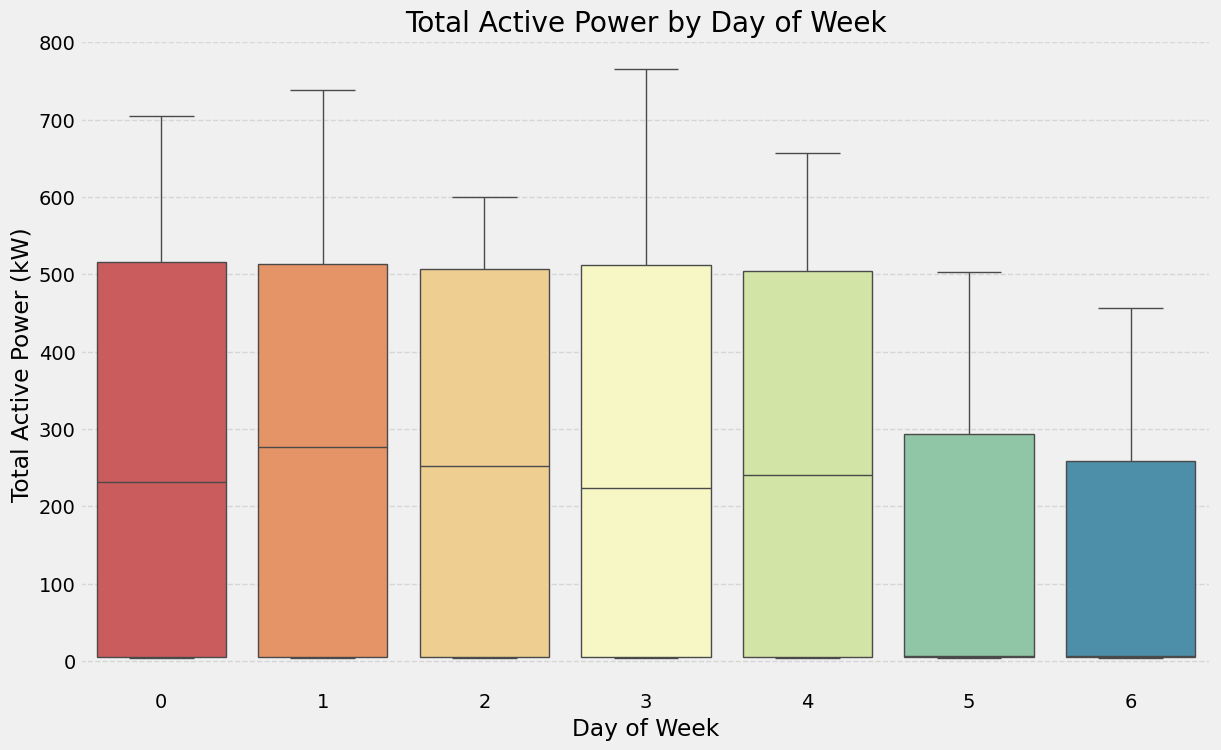

In [ ]:
fig, ax = plt.subplots(figsize=(13,8))
sns.boxplot(data=df, x='dayofweek', y='activePowerT', ax=ax, palette='Spectral')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Active Power (kW)')
ax.set_title('Total Active Power by Day of Week')

fig.savefig('/content/drive/MyDrive/Images/Preliminary Analysis/Day of Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Relationship between Month & Total Active Power

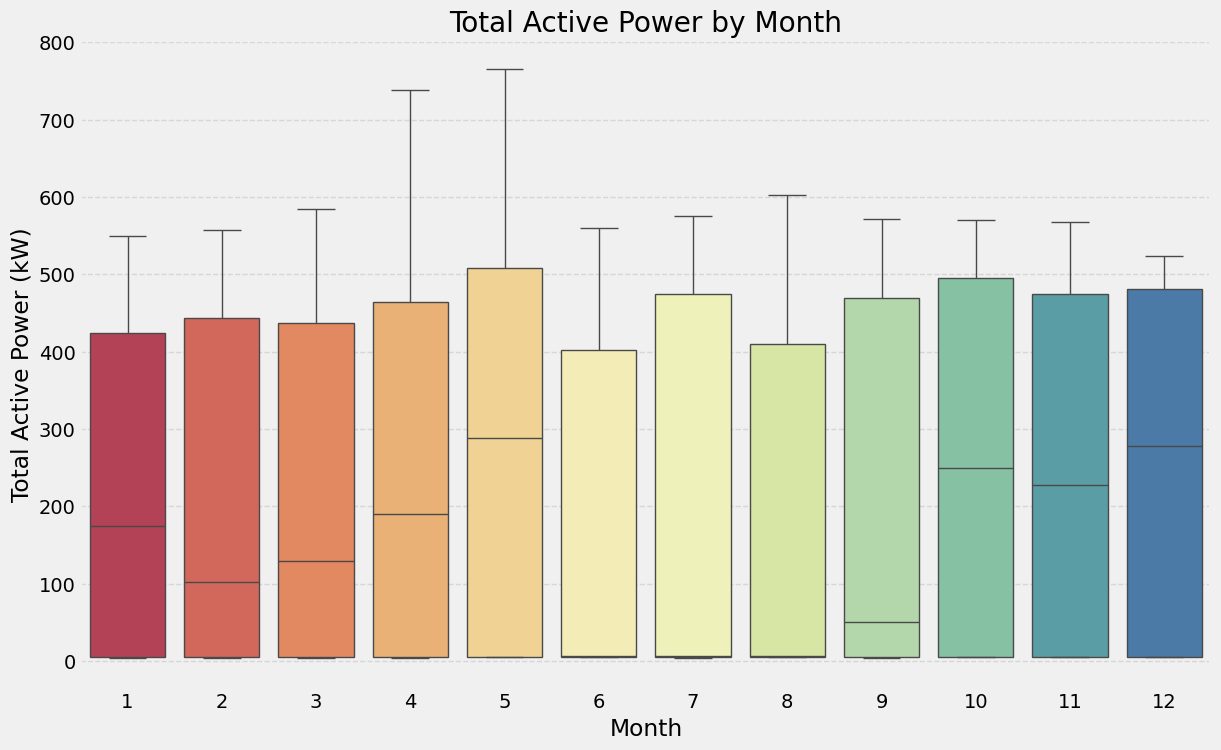

In [ ]:
fig, ax = plt.subplots(figsize=(13,8))
sns.boxplot(data=df, x='month', y='activePowerT', ax=ax, palette='Spectral')
ax.set_xlabel('Month')
ax.set_ylabel('Total Active Power (kW)')
ax.set_title('Total Active Power by Month')

fig.savefig('/content/drive/MyDrive/Images/Preliminary Analysis/Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

It is observed that the month of May has a slightly higher power consumption due to study and exam week, whereas there is a slight lower power consumption during June as the university has entered the summer semester, where most undergraduate classes have finished.